In [1]:
#import mortality rate of under 5, for all country
#Data Preparation
!pip install pycountry
import pandas as pd
import pycountry

url = "https://ourworldindata.org/grapher/under-5-mortality-rate-sdgs.csv?v=1&csvType=full&useColumnShortNames=true"
mortality_under_5 = pd.read_csv(url, storage_options={'User-Agent': 'Our World In Data data fetch/1.0'})
print(mortality_under_5.head())

#The mortality rate was collected in per 100, the rate was coverted to per 1000 by multipying per 100 to work with the general recorded rate of per 1000
mortality_under_5["per_1000"] = mortality_under_5["observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births"] * 10
mortality_under_5.head()

#The name of countries and their ISO code in existence
countries = []
for c in pycountry.countries:
    countries.append({
        'country_name': c.name,
        'iso_alpha3': c.alpha_3
    })

iso_data = pd.DataFrame(countries).sort_values('country_name').reset_index(drop=True)
print(iso_data.head())

#Rename the column that contains the code for each country of iso data, so it can be merge with under_5 mortality data
iso_data = iso_data.rename(columns={'iso_alpha3': 'code', "country_name":"entity"})
iso_data.head()

#Merge under_5_mertality data on the left with iso_data so as to filter the data to all country,
#because the under_5_mortality data as some world back indicator in between which does not belong to any country
mortality_under_5_new = pd.merge(mortality_under_5, iso_data, on=['code', "entity"], how='left')
mortality_under_5_new.head()

#Validating my new data
print(mortality_under_5.shape)
print(mortality_under_5_new.shape)

#Then merge isn't the proper method, i will try filter method
mortality_under_5_new_2 = mortality_under_5[mortality_under_5["code"].isin(iso_data["code"])]
print(mortality_under_5_new_2.shape)
mortality_under_5_new_2.head()

#validating if we have all countries in the list
print(mortality_under_5_new_2["code"].unique())
unique_coutries = mortality_under_5_new_2["code"].unique()
print(len(unique_coutries))

#Importing data for income category for each country
import requests
import pandas as pd

# Pull country metadata including income classification
url = "https://api.worldbank.org/v2/country?format=json&per_page=300"
response = requests.get(url)
data = response.json()[1]
# index 0 is pagination info, index 1 is the actual data

# Flatten the nested structure
income_level = pd.DataFrame([
    {
        "Code": c["id"],
        "country_name": c["name"],
        "income_group": c["incomeLevel"]["value"],
        "region": c["region"]["value"]
    }
    for c in data
])

# Drop non-country aggregates (World Bank includes regional groupings here too)
income_level = income_level[income_level["income_group"] != "Aggregates"]

print(income_level["income_group"].unique())
income_level.head()

#Now i have my income level data, so i will like extract two columns from it to the mortarlity data
mortality_under_5_new_2["income_level"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('Code')['income_group'])
mortality_under_5_new_2["regions"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('Code')['region'])
print(mortality_under_5_new_2.head())
print(mortality_under_5_new_2["income_level"].unique())
print(mortality_under_5_new_2["regions"].unique())


#I waant to drop missing value in the data
mort_und_5_new_2_dropna = mortality_under_5_new_2.dropna()
print(mort_und_5_new_2_dropna.shape)
print(mort_und_5_new_2_dropna.isna().sum())

#Since my interest is working on years from year 2000 to later year.
mort_und_5_new_2_dropna_2000 = mort_und_5_new_2_dropna[mort_und_5_new_2_dropna["year"] >= 2000]
print(mort_und_5_new_2_dropna_2000.shape)

#validating which countries have dropped since i applied dropping missing valuea nd also
#applied filtered for years above 2000
print(mort_und_5_new_2_dropna_2000["code"].unique())
unique_coutries_2 = mort_und_5_new_2_dropna_2000["code"].unique()
print(len(unique_coutries_2))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 23.1 MB/s eta 0:00:00
        entity code  year  \
0  Afghanistan  AFG  1957   
1  Afghanistan  AFG  1958   
2  Afghanistan  AFG  1959   
3  Afghanistan  AFG  1960   
4  Afghanistan  AFG  1961   

   observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births  
0                                          36.819660                                                                                
1                                          36.206852                                                                                
2                                          35.644524                                                                                
3                                          35.055080                                                                                
4                                          34.519325                               

/tmp/ipykernel_4952/2638929022.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortality_under_5_new_2["income_level"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('Code')['income_group'])
/tmp/ipykernel_4952/2638929022.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortality_under_5_new_2["regions"] = mortality_under_5_new_2[mortality_under_5_new_2['code'].isin(income_level['Code'])]['code'].map(income_level.set_index('C

In [2]:
# Rename data
mortality_under_5 = mort_und_5_new_2_dropna_2000
print(mortality_under_5.head())

         entity code  year  \
43  Afghanistan  AFG  2000   
44  Afghanistan  AFG  2001   
45  Afghanistan  AFG  2002   
46  Afghanistan  AFG  2003   
47  Afghanistan  AFG  2004   

    observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births  \
43                                          13.170724                                                                                 
44                                          12.747986                                                                                 
45                                          12.307344                                                                                 
46                                          11.854750                                                                                 
47                                          11.394402                                                                                 

     per

In [3]:
#Summary statistics based on regions
regional_mortality_U_5 = mortality_under_5.groupby('regions').describe()
print(regional_mortality_U_5)

                                                     year                    \
                                                    count    mean       std   
regions                                                                       
East Asia & Pacific                                 750.0  2012.0  7.215915   
Europe & Central Asia                              1275.0  2012.0  7.213932   
Latin America & Caribbean                           875.0  2012.0  7.215227   
Middle East, North Africa, Afghanistan & Pakistan   575.0  2012.0  7.217381   
North America                                        50.0  2012.0  7.284314   
South Asia                                          150.0  2012.0  7.235260   
Sub-Saharan Africa                                 1200.0  2012.0  7.214109   

                                                                           \
                                                      min     25%     50%   
regions                                                

In [4]:
#Importing Population data for all coountries from 2000 to 2024

import requests

def get_population_data(start_year=2000, end_year=2024):
    """
    Pulls total population by country from World Bank API.
    Indicator SP.POP.TOTL = Population, total
    """
    url = "http://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL"
    params = {
        "date": f"{start_year}:{end_year}",
        "format": "json",
        "per_page": 20000  # large enough to get all countries/years in one call
    }

    response = requests.get(url, params=params)
    data = response.json()

    records = data[1]  # data[0] is metadata (pagination info), data[1] is the actual records

    rows = []
    for r in records:
        rows.append({
            "country_name": r["country"]["value"],
            "iso_alpha3": r["countryiso3code"],
            "year": int(r["date"]),
            "population": r["value"]
        })

    all_pop = pd.DataFrame(rows)
    return all_pop

population = get_population_data(2000, 2024)
print(population.head())
print(population.shape)

                  country_name iso_alpha3  year   population
0  Africa Eastern and Southern        AFE  2024  769280888.0
1  Africa Eastern and Southern        AFE  2023  750491370.0
2  Africa Eastern and Southern        AFE  2022  731821393.0
3  Africa Eastern and Southern        AFE  2021  713090928.0
4  Africa Eastern and Southern        AFE  2020  694446100.0
(6625, 4)


In [5]:
print(population["country_name"].unique)

<bound method Series.unique of 0       Africa Eastern and Southern
1       Africa Eastern and Southern
2       Africa Eastern and Southern
3       Africa Eastern and Southern
4       Africa Eastern and Southern
                   ...             
6620                       Zimbabwe
6621                       Zimbabwe
6622                       Zimbabwe
6623                       Zimbabwe
6624                       Zimbabwe
Name: country_name, Length: 6625, dtype: object>


In [6]:
#Rename populatio column name
population = population.rename(columns={'country_name': 'entity', "iso_alpha3":"code"})
print(population.head())

                        entity code  year   population
0  Africa Eastern and Southern  AFE  2024  769280888.0
1  Africa Eastern and Southern  AFE  2023  750491370.0
2  Africa Eastern and Southern  AFE  2022  731821393.0
3  Africa Eastern and Southern  AFE  2021  713090928.0
4  Africa Eastern and Southern  AFE  2020  694446100.0


In [7]:
#Joining populaton data to the mortality_under_5
mortality_under_5_pop = pd.merge(mortality_under_5, population, on=['entity', "code", 'year'], how='left')
print(mortality_under_5.shape)
print(mortality_under_5_pop.shape)
print(mortality_under_5_pop.shape)
print(mortality_under_5_pop.head())

(4875, 7)
(4875, 8)
(4875, 8)
        entity code  year  \
0  Afghanistan  AFG  2000   
1  Afghanistan  AFG  2001   
2  Afghanistan  AFG  2002   
3  Afghanistan  AFG  2003   
4  Afghanistan  AFG  2004   

   observation_value__indicator_child_mortality_rate__sex_total__wealth_quintile_total__unit_of_measure_deaths_per_100_live_births  \
0                                          13.170724                                                                                 
1                                          12.747986                                                                                 
2                                          12.307344                                                                                 
3                                          11.854750                                                                                 
4                                          11.394402                                                                         

In [8]:
#To get the possible total number of under 5 mortality per year of all countries
mortality_under_5_pop['weighted'] = mortality_under_5_pop['per_1000'] * mortality_under_5_pop['population']
global_weighted = mortality_under_5_pop.groupby('year').apply(
    lambda x: x['weighted'].sum() / x['population'].sum()
).reset_index(name='global_u5mr')

/tmp/ipykernel_4952/2072758982.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  global_weighted = mortality_under_5_pop.groupby('year').apply(


In [9]:
print(global_weighted.describe())
print(global_weighted)

              year  global_u5mr
count    25.000000    25.000000
mean   2012.000000    37.544106
std       7.359801    10.398820
min    2000.000000    24.529073
25%    2006.000000    28.503237
50%    2012.000000    35.027634
75%    2018.000000    44.988110
max    2024.000000    58.134652
    year  global_u5mr
0   2000    58.134652
1   2001    55.994267
2   2002    53.523776
3   2003    51.277125
4   2004    49.449335
5   2005    47.067049
6   2006    44.988110
7   2007    43.082360
8   2008    41.523901
9   2009    39.844452
10  2010    38.063773
11  2011    36.453530
12  2012    35.027634
13  2013    33.711465
14  2014    32.675076
15  2015    31.584637
16  2016    30.594187
17  2017    29.635276
18  2018    28.503237
19  2019    27.764965
20  2020    26.960300
21  2021    26.702119
22  2022    26.255158
23  2023    25.257184
24  2024    24.529073


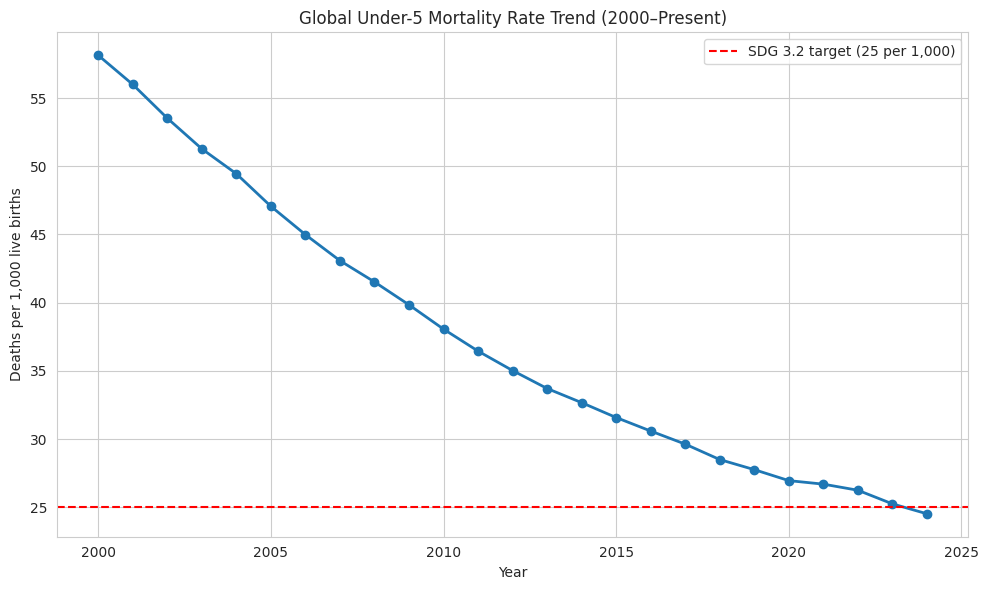

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
plt.plot(global_weighted['year'], global_weighted['global_u5mr'], marker='o', linewidth=2)
plt.axhline(y=25, color='red', linestyle='--', label='SDG 3.2 target (25 per 1,000)')
plt.title('Global Under-5 Mortality Rate Trend (2000–Present)')
plt.xlabel('Year')
plt.ylabel('Deaths per 1,000 live births')
plt.legend()
plt.tight_layout()
# now save
#plt.savefig(f'[outputs]/figures/global_trend_since_2000.png', dpi=200)
plt.show()

In [11]:
#Identifying the lowest and highest mortality_under_5 countries
latest_year = mortality_under_5_pop['year'].max()
latest = mortality_under_5_pop[mortality_under_5_pop ['year'] == latest_year]

top10_lowest = latest.nsmallest(10, 'per_1000')[['entity', 'per_1000']]
top10_highest = latest.nlargest(10, 'per_1000')[['entity', 'per_1000']]

print("Highest U5MR:\n", top10_highest)
print("\nLowest U5MR:\n", top10_lowest)

Highest U5MR:
                             entity    per_1000
3174                       Nigeria  115.649430
3149                         Niger  110.720350
4024                       Somalia  101.065720
874                           Chad   97.257530
4099                   South Sudan   96.711330
1799                        Guinea   92.144600
3899                  Sierra Leone   90.499580
849       Central African Republic   89.727780
1174  Democratic Republic of Congo   89.678135
2449                       Liberia   86.387670

Lowest U5MR:
           entity  per_1000
3749  San Marino  1.259518
1449     Estonia  2.015613
2524  Luxembourg  2.181574
3974    Slovenia  2.258975
399      Belarus  2.331336
1549     Finland  2.352497
2899  Montenegro  2.383296
4224      Sweden  2.406118
2174       Japan  2.433754
3249      Norway  2.487414


In [12]:
#Fastest improver
first_year = mortality_under_5_pop['year'].min()
last_year = mortality_under_5_pop['year'].max()

pivot = mortality_under_5_pop[mortality_under_5_pop['year'].isin([first_year, last_year])].pivot(
    index=['entity', 'code'], columns='year', values='per_1000'
).reset_index()

pivot.columns = ['entity', 'code', 'rate_first', 'rate_last']
pivot['abs_change'] = pivot['rate_first'] - pivot['rate_last']
pivot['pct_change'] = (pivot['abs_change'] / pivot['rate_first']) * 100

fastest_improvers = pivot.sort_values('pct_change', ascending=False).head(10)
print(fastest_improvers)

                    entity code  rate_first  rate_last  abs_change  pct_change
104               Maldives  MDV   39.482270   5.438741   34.043529   86.224852
36                   China  CHN   36.639075   5.723935   30.915140   84.377512
150  Sao Tome and Principe  STP   82.167210  13.554487   68.612723   83.503776
127            North Korea  PRK  100.234640  16.665504   83.569136   83.373508
115             Montenegro  MNE   14.203769   2.383296   11.820473   83.220677
94                  Latvia  LVA   14.298372   2.500961   11.797411   82.508768
29                Cambodia  KHM  105.178950  18.410044   86.768906   82.496456
128        North Macedonia  MKD   16.006331   2.803139   13.203192   82.487308
15                 Belarus  BLR   12.761927   2.331336   10.430591   81.732098
57                 Estonia  EST   11.031847   2.015613    9.016234   81.729147


In [13]:
#Percentile snapshot (latest year)
#latest = df[df['year'] == df['year'].max()]

percentiles = latest['per_1000'].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
print(percentiles)

0.10     3.207068
0.25     5.882971
0.50    14.955003
0.75    36.721355
0.90    60.944291
Name: per_1000, dtype: float64


In [14]:
#Mean Vs Median
mean_val = latest['per_1000'].mean()
median_val = latest['per_1000'].median()
print(f"Mean: {mean_val:.1f}, Median: {median_val:.1f}, Gap: {mean_val - median_val:.1f}")

Mean: 24.3, Median: 15.0, Gap: 9.3


In [15]:
# Simple linear trend to estimate 2030 trajectory
from numpy.polynomial import polynomial as P

years = global_weighted['year'].values
rates = global_weighted['global_u5mr'].values

coeffs = P.polyfit(years, rates, 1)  # linear fit
projected_2030 = P.polyval(2030, coeffs)

print(f"Current rate ({latest_year}): {rates[-1]:.1f}")
print(f"Projected 2030 rate (linear trend): {projected_2030:.1f}")
print(f"SDG target: 25")
print(f"On track: {'Yes' if projected_2030 <= 25 else 'No'}")

Current rate (2024): 24.5
Projected 2030 rate (linear trend): 12.6
SDG target: 25
On track: Yes


In [16]:
#Decade over decade comparison
def get_decade(year):
    if 2000 <= year <= 2009:
        return '2000s'
    elif 2010 <= year <= 2019:
        return '2010s'
    else:
        return '2020s'

global_weighted['decade'] = global_weighted['year'].apply(get_decade)

decade_avg = global_weighted.groupby('decade')['global_u5mr'].mean().reset_index()
print(decade_avg)

  decade  global_u5mr
0  2000s    48.488503
1  2010s    32.401378
2  2020s    25.940767


In [17]:
#Volatility / year-over-year variance
global_weighted['pct_change'] = global_weighted['global_u5mr'].pct_change() * 100
print(global_weighted[['year', 'global_u5mr', 'pct_change']])
print("Std dev of year-over-year % change:", global_weighted['pct_change'].std())

    year  global_u5mr  pct_change
0   2000    58.134652         NaN
1   2001    55.994267   -3.681770
2   2002    53.523776   -4.412043
3   2003    51.277125   -4.197482
4   2004    49.449335   -3.564533
5   2005    47.067049   -4.817629
6   2006    44.988110   -4.416974
7   2007    43.082360   -4.236119
8   2008    41.523901   -3.617396
9   2009    39.844452   -4.044534
10  2010    38.063773   -4.469077
11  2011    36.453530   -4.230382
12  2012    35.027634   -3.911543
13  2013    33.711465   -3.757517
14  2014    32.675076   -3.074293
15  2015    31.584637   -3.337221
16  2016    30.594187   -3.135858
17  2017    29.635276   -3.134292
18  2018    28.503237   -3.819902
19  2019    27.764965   -2.590135
20  2020    26.960300   -2.898132
21  2021    26.702119   -0.957633
22  2022    26.255158   -1.673880
23  2023    25.257184   -3.801058
24  2024    24.529073   -2.882786
Std dev of year-over-year % change: 0.8971229467338557


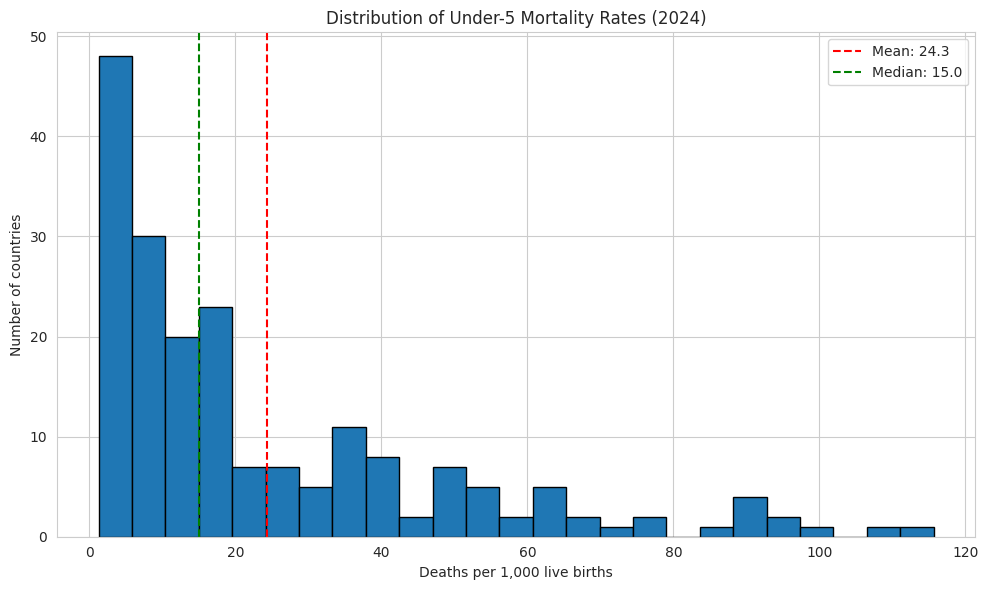

In [18]:
#Histogram for latest year distribution
plt.figure(figsize=(10,6))
plt.hist(latest['per_1000'].dropna(), bins=25, edgecolor='black')
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
plt.title(f'Distribution of Under-5 Mortality Rates ({last_year})')
plt.xlabel('Deaths per 1,000 live births')
plt.ylabel('Number of countries')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
#Global Under 5 mortality rate by decade
def get_decade(year):
    if 2000 <= year <= 2009:
        return '2000s'
    elif 2010 <= year <= 2019:
        return '2010s'
    else:
        return '2020s'

mortality_under_5_pop['decade'] = mortality_under_5_pop['year'].apply(get_decade)

decade_avg_pop = mortality_under_5_pop.groupby('decade')['per_1000'].mean().reset_index()
print(decade_avg_pop)

  decade   per_1000
0  2000s  46.068601
1  2010s  31.796028
2  2020s  25.970428


<Figure size 800x600 with 0 Axes>

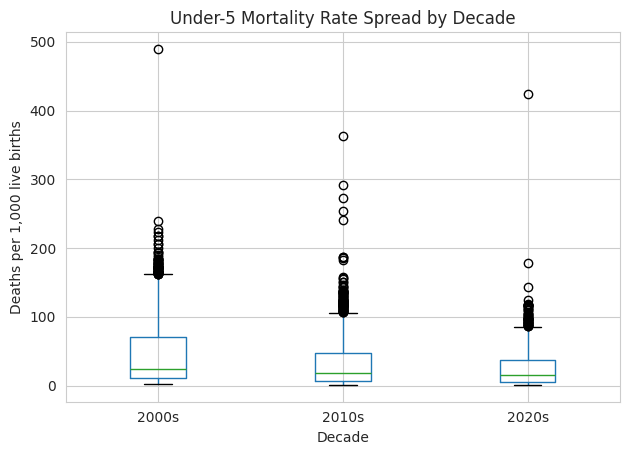

In [20]:
#Box plot by decades
plt.figure(figsize=(8,6))
mortality_under_5_pop.boxplot(column='per_1000', by='decade')
plt.title('Under-5 Mortality Rate Spread by Decade')
plt.suptitle('')  # removes default pandas subtitle
plt.xlabel('Decade')
plt.ylabel('Deaths per 1,000 live births')
plt.tight_layout()
plt.show()

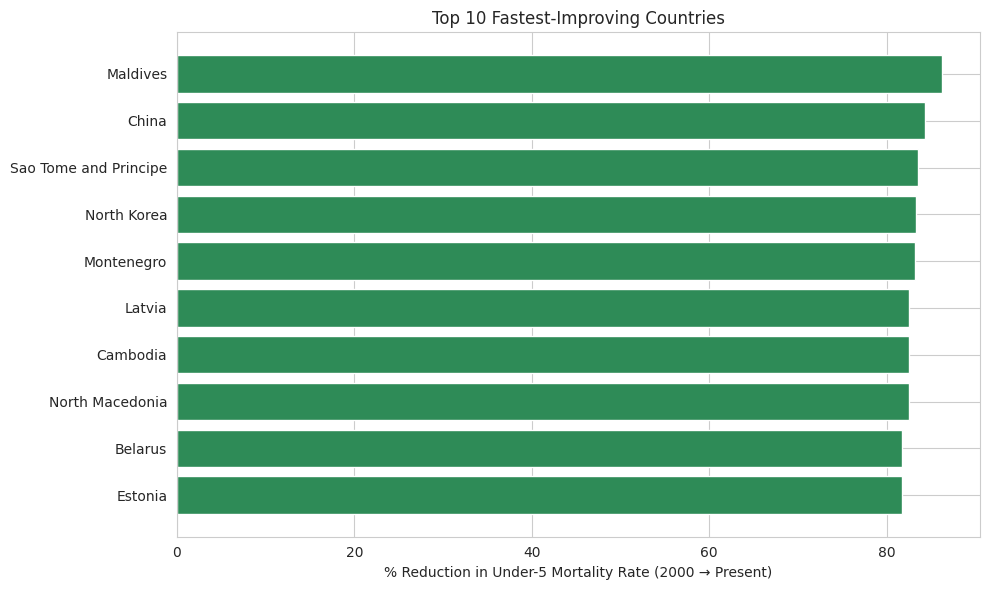

In [21]:
plt.figure(figsize=(10,6))
plt.barh(fastest_improvers['entity'], fastest_improvers['pct_change'], color='seagreen')
plt.xlabel('% Reduction in Under-5 Mortality Rate (2000 → Present)')
plt.title('Top 10 Fastest-Improving Countries')
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()

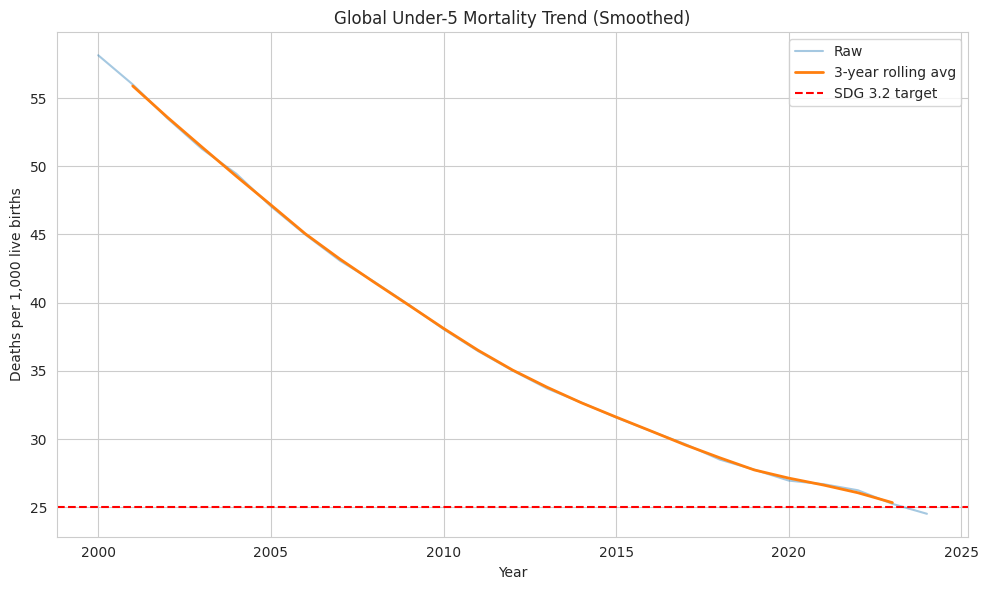

In [22]:
#Rolling
global_weighted['rolling_avg'] = global_weighted['global_u5mr'].rolling(window=3, center=True).mean()

plt.figure(figsize=(10,6))
plt.plot(global_weighted['year'], global_weighted['global_u5mr'], alpha=0.4, label='Raw')
plt.plot(global_weighted['year'], global_weighted['rolling_avg'], linewidth=2, label='3-year rolling avg')
plt.axhline(y=25, color='red', linestyle='--', label='SDG 3.2 target')
plt.title('Global Under-5 Mortality Trend (Smoothed)')
plt.xlabel('Year')
plt.ylabel('Deaths per 1,000 live births')
plt.legend()
plt.tight_layout()
plt.show()